# Phase 1 Supervised Fine-Tuning Kaggle Lab - Qwen 0.5B and Gemma 3 1B

This is the Kaggle version of the Colab notebook. It keeps the same hands-on lab flow, but swaps Colab-specific paths and secrets for Kaggle equivalents.

Before running:

1. In Kaggle Notebook settings, set **Accelerator -> GPU**.
2. Turn **Internet -> On** so Hugging Face datasets/models and GitHub clone work.
3. For Gemma, add a Kaggle secret named `HF_TOKEN` with a Hugging Face token that has access to `google/gemma-3-1b-it`.
4. Optional: add `WANDB_API_KEY` if you want online Weights & Biases logging later.

Two paths:

- **Lab path:** visible training loop you can inspect cell by cell.
- **Production path:** one-command Trainer CLI once the lab path is healthy.

Important Gemma note: Gemma 3 1B needs the memory recipe on small GPUs: batch size 1, gradient accumulation, gradient checkpointing, and `bitsandbytes.optim.AdamW8bit`.

## Step 1 - verify the GPU

If this errors or shows no GPU, check Kaggle Notebook settings: Accelerator must be set to GPU.

In [1]:
!nvidia-smi

Sun May 10 20:58:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))


True
2
Tesla T4


## Step 2 - clone the repo and install dependencies

Kaggle's writable working directory is `/kaggle/working`. We clone there, then install the repo in editable mode.

In [3]:
import sys
SRC_DIR = "/kaggle/working/finpost/src"

sys.path.insert(0, SRC_DIR)

for name in list(sys.modules):
    if name == "finpost" or name.startswith("finpost."):
        del sys.modules[name]


In [ ]:
%cd /kaggle/working
!test -d finpost || git clone https://github.com/shannan-liu1/finpost.git
%cd /kaggle/working/finpost
!pip install -q -e .

## Step 3 - imports and Kaggle path fix

This confirms that Python imports `finpost` from `/kaggle/working/finpost/src`, then confirms CUDA from inside PyTorch.

In [4]:
import os, sys, pathlib

REPO_DIR = "/kaggle/working/finpost"
SRC_DIR = f"{REPO_DIR}/src"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/shannan-liu1/finpost.git /kaggle/working/finpost

%cd /kaggle/working/finpost

# Put local source package first.
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Clear any wrongly-imported finpost package.
for name in list(sys.modules):
    if name == "finpost" or name.startswith("finpost."):
        del sys.modules[name]

import finpost
print("finpost loaded from:", finpost.__file__)


/kaggle/working/finpost
finpost loaded from: /kaggle/working/finpost/src/finpost/__init__.py


In [5]:
from __future__ import annotations

import gc
import importlib
import os
import subprocess
import sys
from pathlib import Path
from typing import Any

REPO_ROOT = '/kaggle/working/finpost'
SRC_PATH = os.path.join(REPO_ROOT, 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

if 'finpost' in sys.modules:
    importlib.reload(sys.modules['finpost'])

import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from finpost.training.config import Config, DataConfig, ModelConfig, PackingConfig, TrainingConfig
from finpost.training.dataset import make_loaders
from finpost.training.optim import build_lr_scheduler, build_optimizer
from finpost.training.sft import compute_masked_ce_loss

print('finpost import path:', os.path.join(SRC_PATH, 'finpost'))
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
    print('Capability:', torch.cuda.get_device_capability(0))
    print('VRAM GB:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

finpost import path: /kaggle/working/finpost/src/finpost
CUDA available: True
Device: Tesla T4
Capability: (7, 5)
VRAM GB: 15.64


## Step 4 - choose the run profile

Change only `RUN_PRESET` for the common paths:

- `qwen_500m`: default and most likely to fit.
- `gemma_1b_gpu`: larger stress test. Requires `HF_TOKEN` secret if the model is gated for your account.

Kaggle may give T4 or P100-class GPUs. `float16` is the safest default across those. If Kaggle gives you a newer GPU with good bfloat16 support, you can switch `dtype` to `bfloat16`.

In [6]:
RUN_PRESET = 'qwen_500m'      # 'qwen_500m' or 'gemma_1b_gpu'
NUM_STEPS = 100                 # 50-100 is enough to prove the loop and see a loss trace
DATA_SOURCES = ['gsm8k']         # fast lab path; production config uses gsm8k + math

PRESETS = {
    'qwen_500m': {
        'model_id': 'Qwen/Qwen2.5-0.5B',
        'batch_size': 1,
        'grad_accum_steps': 4,
        'max_seq_len': 1024,
        'lr': 1e-5,
        'dtype': 'float32',
        'use_safetensors': True,
        'gradient_checkpointing': True,
        'use_8bit_adamw': False,
        'hf_token_secret': None,
        'checkpoint_dir': '/kaggle/working/qwen2_5_0_5b_checkpoint_100',
    },
    'gemma_1b_gpu': {
        'model_id': 'google/gemma-3-1b-it',
        'batch_size': 1,
        'grad_accum_steps': 4,
        'max_seq_len': 1024,
        'lr': 1e-5,
        'dtype': 'float16',
        'use_safetensors': True,
        'gradient_checkpointing': True,
        'use_8bit_adamw': True,
        'hf_token_secret': 'HF_TOKEN',
        'checkpoint_dir': '/kaggle/working/gemma3_1b_checkpoint_100',
    },
}

profile = PRESETS[RUN_PRESET]
print('Run profile')
for key, value in profile.items():
    print(f'  {key}: {value}')
print('  data_sources:', DATA_SOURCES)
print('  num_steps:', NUM_STEPS)
print('  effective_batch:', profile['batch_size'] * profile['grad_accum_steps'])

Run profile
  model_id: Qwen/Qwen2.5-0.5B
  batch_size: 1
  grad_accum_steps: 4
  max_seq_len: 1024
  lr: 1e-05
  dtype: float32
  use_safetensors: True
  gradient_checkpointing: True
  use_8bit_adamw: False
  hf_token_secret: None
  checkpoint_dir: /kaggle/working/qwen2_5_0_5b_checkpoint_100
  data_sources: ['gsm8k']
  num_steps: 100
  effective_batch: 4


## Step 5 - load model and build the training config

This uses the same Pydantic config objects as the production trainer, but keeps the knobs visible in the notebook.

In [7]:
from huggingface_hub import snapshot_download

if RUN_PRESET == "qwen_500m":
    MODEL_DIR = "/kaggle/working/models/qwen2_5_0_5b"
    snapshot_download(
        repo_id="Qwen/Qwen2.5-0.5B",
        local_dir=MODEL_DIR,
        allow_patterns=[
            "*.json",
            "*.safetensors",
            "tokenizer.*",
            "vocab.json",
            "merges.txt",
        ],
    )

profile["model_id"] = MODEL_DIR
print("Using local model:", profile["model_id"])


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Using local model: /kaggle/working/models/qwen2_5_0_5b


In [8]:
warmup_steps = max(1, min(NUM_STEPS // 10, NUM_STEPS - 1))

config = Config(
    model=ModelConfig(
        base_model_id=profile["model_id"],
        dtype=profile['dtype'],
        use_safetensors=profile['use_safetensors'],
    ),
    data=DataConfig(
        sources=DATA_SOURCES,
        val_split_pct=5.0,
        seed=42,
    ),
    training=TrainingConfig(
        max_steps=NUM_STEPS,
        warmup_steps=warmup_steps,
        lr=profile['lr'],
        weight_decay=0.01,
        grad_accum_steps=profile['grad_accum_steps'],
        grad_clip=1.0,
        val_every_n_steps=max(10, NUM_STEPS // 2),
        checkpoint_every_n_steps=max(25, NUM_STEPS),
        per_device_batch_size=profile['batch_size'],
    ),
    packing=PackingConfig(
        max_seq_len=profile['max_seq_len'],
        isolate_documents=True,
    ),
)

print('Config built')
print('  model:', config.model.base_model_id)
print('  dtype:', config.model.dtype)
print('  sources:', config.data.sources)
print('  batch:', config.training.per_device_batch_size)
print('  grad_accum_steps:', config.training.grad_accum_steps)
print('  max_seq_len:', config.packing.max_seq_len)
print('  warmup_steps:', config.training.warmup_steps)
print('  lr:', config.training.lr)

Config built
  model: /kaggle/working/models/qwen2_5_0_5b
  dtype: float32
  sources: ['gsm8k']
  batch: 1
  grad_accum_steps: 4
  max_seq_len: 1024
  warmup_steps: 10
  lr: 1e-05


## Step 6 - install optional memory dependency

Gemma 3 1B needs 8-bit AdamW, provided by `bitsandbytes`. Qwen 0.5B does not need it.

In [9]:
if profile['use_8bit_adamw']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'bitsandbytes'], check=True)
    print('bitsandbytes installed')
else:
    print('bitsandbytes not needed for this profile')

bitsandbytes not needed for this profile


## Step 7 - load tokenizer and model

This cell reads Kaggle secrets for gated Hugging Face models and prints memory after loading.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    raise RuntimeError("GPU runtime is not active")

print("device:", device)
print("gpu:", torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


In [14]:
tokenizer = AutoTokenizer.from_pretrained(
    config.model.base_model_id,
    local_files_only=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)

torch_dtype = getattr(torch, config.model.dtype)

model = AutoModelForCausalLM.from_pretrained(
    config.model.base_model_id,
    dtype=torch_dtype,              # new Transformers spelling
    use_safetensors=True,
    local_files_only=True,
).to(device)

if profile["gradient_checkpointing"]:
    model.gradient_checkpointing_enable()
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = False

model.train()

print("GPU memory allocated GB:", round(torch.cuda.memory_allocated() / 1e9, 2))

pad_token_id: 151643
eos_token_id: 151643


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

GPU memory allocated GB: 5.93


## Step 8 - build loaders and inspect the first batch

This catches bad packing, masking, or sequence-length settings before training.

In [15]:
print('Building data loaders...')
train_loader, val_loader = make_loaders(config, tokenizer)
print('Train examples:', len(train_loader.dataset))
print('Val examples:', len(val_loader.dataset))

peek = next(iter(train_loader))
print('First batch shapes')
print('  input_ids:', tuple(peek['input_ids'].shape))
print('  labels:', tuple(peek['labels'].shape))
print('  attention_mask:', tuple(peek['attention_mask'].shape))
print('  position_ids:', tuple(peek['position_ids'].shape))
print('  response tokens:', int((peek['labels'] != -100).sum().item()))

Building data loaders...
Train examples: 7099
Val examples: 374
First batch shapes
  input_ids: (1, 149)
  labels: (1, 149)
  attention_mask: (1, 1, 149, 149)
  position_ids: (1, 149)
  response tokens: 72


### Shape reminder

- `input_ids`: token IDs fed into the model.
- `labels`: same length as input, but prompt/padding positions are `-100` so they do not contribute to loss.
- `attention_mask`: what each token can attend to. With isolated packing this is 4D.
- `position_ids`: token position inside each packed document/example.
- `response tokens`: count of supervised tokens, i.e. where `labels != -100`.

## Step 9 - build optimizer and scheduler

The default uses the repo's AdamW factory. The Gemma profile swaps in `bitsandbytes.optim.AdamW8bit` to keep optimizer state small enough.

In [17]:
if profile['use_8bit_adamw']:
    import bitsandbytes as bnb

    optimizer = bnb.optim.AdamW8bit(
        model.parameters(),
        lr=config.training.lr,
        weight_decay=config.training.weight_decay,
    )
else:
    optimizer = build_optimizer(
        model,
        lr=config.training.lr,
        weight_decay=config.training.weight_decay,
    )

scheduler = build_lr_scheduler(
    optimizer,
    total_steps=config.training.max_steps,
    warmup_steps=config.training.warmup_steps,
)
print('Optimizer:', type(optimizer).__name__)
print('Initial lr:', optimizer.param_groups[0]['lr'])

Optimizer: AdamW
Initial lr: 0.0


## Step 10 - run the visible lab loop

This uses the same core pieces as the production trainer: packed batches, masked cross-entropy, gradient accumulation, gradient clipping, and the warmup/cosine scheduler.

In [20]:
batch = next(iter(train_loader))

# Move only tensor fields to GPU; leave metadata lists alone.
batch = {
    k: v.to(device) if torch.is_tensor(v) else v
    for k, v in batch.items()
}

print(batch.keys())
for k, v in batch.items():
    print(k, type(v), getattr(v, "shape", None))


dict_keys(['input_ids', 'labels', 'position_ids', 'document_boundaries', 'attention_mask'])
input_ids <class 'torch.Tensor'> torch.Size([1, 195])
labels <class 'torch.Tensor'> torch.Size([1, 195])
position_ids <class 'torch.Tensor'> torch.Size([1, 195])
document_boundaries <class 'list'> None
attention_mask <class 'torch.Tensor'> torch.Size([1, 1, 195, 195])


In [21]:
with torch.no_grad():
    out = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"].bool(),
        position_ids=batch["position_ids"],
    )
    loss = compute_masked_ce_loss(out.logits, batch["labels"])

print("forward logits finite:", torch.isfinite(out.logits).all().item())
print("forward loss:", loss.item())
print("supervised tokens:", int((batch["labels"] != -100).sum()))


forward logits finite: True
forward loss: 0.6721304059028625
supervised tokens: 127


In [22]:
losses: list[float] = []
loader_iter = iter(train_loader)
grad_accum = config.training.grad_accum_steps

print(f'Running {NUM_STEPS} optimizer steps')
for step in range(1, NUM_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)
    step_loss = 0.0
    response_tokens = 0
    rows = 0
    seq_len = 0

    for _ in range(grad_accum):
        try:
            batch = next(loader_iter)
        except StopIteration:
            loader_iter = iter(train_loader)
            batch = next(loader_iter)

        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        attention_mask = batch['attention_mask'].to(device).bool()
        position_ids = batch['position_ids'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
        )
        loss = compute_masked_ce_loss(outputs.logits, labels)
        (loss / grad_accum).backward()

        step_loss += float(loss.detach().float().item()) / grad_accum
        response_tokens += int((batch['labels'] != -100).sum().item())
        rows, seq_len = batch['input_ids'].shape

    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        config.training.grad_clip,
        error_if_nonfinite=True,
    )

    optimizer.step()
    for name, param in model.named_parameters():
        if param.requires_grad and not torch.isfinite(param).all():
            raise RuntimeError(f"nonfinite parameter after step {step}: {name}")

    scheduler.step()

    losses.append(step_loss)
    print(
        f'step {step:03d}: loss={step_loss:.4f} '
        f'lr={optimizer.param_groups[0]["lr"]:.2e} '
        f'grad_norm={float(grad_norm):.2f} '
        f'shape=({rows}x{seq_len}) resp_tokens={response_tokens}'
    )

print()
if any(not torch.isfinite(torch.tensor(v)).item() for v in losses):
    print('FAIL: NaN or inf in loss curve')
elif len(losses) > 1 and losses[-1] < losses[0]:
    print(f'OK: loss {losses[0]:.4f} -> {losses[-1]:.4f} (drop {losses[0] - losses[-1]:.4f})')
else:
    print('WARN: loss did not decrease over this short run; inspect the curve and try more steps or a lower LR.')

print('GPU memory allocated after training GB:', round(torch.cuda.memory_allocated() / 1e9, 2))

Running 100 optimizer steps
step 001: loss=1.0412 lr=1.00e-06 grad_norm=35.86 shape=(1x179) resp_tokens=364
step 002: loss=0.8447 lr=2.00e-06 grad_norm=32.27 shape=(1x138) resp_tokens=560
step 003: loss=0.8524 lr=3.00e-06 grad_norm=23.33 shape=(1x254) resp_tokens=601
step 004: loss=0.7424 lr=4.00e-06 grad_norm=19.01 shape=(1x159) resp_tokens=437
step 005: loss=0.7348 lr=5.00e-06 grad_norm=20.25 shape=(1x190) resp_tokens=436
step 006: loss=0.6931 lr=6.00e-06 grad_norm=15.08 shape=(1x215) resp_tokens=501
step 007: loss=1.0016 lr=7.00e-06 grad_norm=18.93 shape=(1x243) resp_tokens=387
step 008: loss=0.5973 lr=8.00e-06 grad_norm=15.07 shape=(1x80) resp_tokens=422
step 009: loss=0.5916 lr=9.00e-06 grad_norm=12.59 shape=(1x202) resp_tokens=607
step 010: loss=0.7714 lr=1.00e-05 grad_norm=16.78 shape=(1x163) resp_tokens=402
step 011: loss=0.5847 lr=1.00e-05 grad_norm=14.35 shape=(1x258) resp_tokens=531
step 012: loss=0.5378 lr=9.99e-06 grad_norm=13.59 shape=(1x105) resp_tokens=576
step 013: los

## Step 11 - plot the loss curve

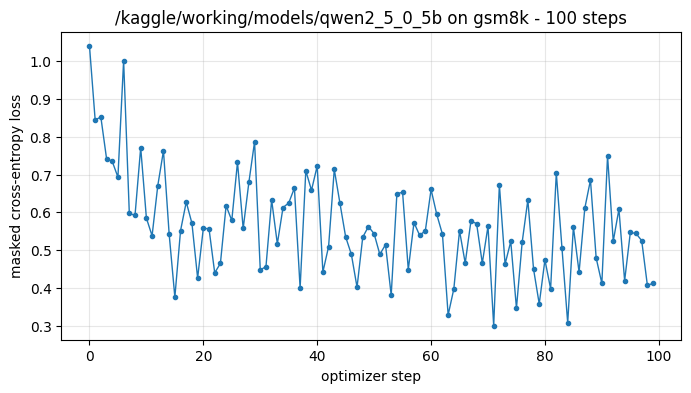

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o', markersize=3, linewidth=1)
plt.xlabel('optimizer step')
plt.ylabel('masked cross-entropy loss')
plt.title(f'{config.model.base_model_id} on {"+".join(config.data.sources)} - {len(losses)} steps')
plt.grid(alpha=0.3)
plt.show()

## Step 12 - save the lab checkpoint

Kaggle lets you download files from `/kaggle/working` after the run. This saves a Hugging Face-format checkpoint for quick experimentation.

In [24]:
CHECKPOINT_DIR = profile['checkpoint_dir']
model.save_pretrained(CHECKPOINT_DIR, safe_serialization=True)
tokenizer.save_pretrained(CHECKPOINT_DIR)
print('Saved to', CHECKPOINT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /kaggle/working/qwen2_5_0_5b_checkpoint_100


## Step 13 - optional: clear memory, reload checkpoint, continue

Run this only if you want to prove reload/continue works. Clearing objects first avoids the out-of-memory pattern from reloading while the old model is still resident.

In [26]:
# Optional reload test.

CHECKPOINT_DIR = profile["checkpoint_dir"]
dtype = getattr(torch, config.model.dtype)

if "model" in globals():
    del model
if "optimizer" in globals():
    del optimizer
if "scheduler" in globals():
    del scheduler

gc.collect()
torch.cuda.empty_cache()
print("GPU memory after cleanup GB:", round(torch.cuda.memory_allocated() / 1e9, 2))

model = AutoModelForCausalLM.from_pretrained(
    CHECKPOINT_DIR,
    dtype=dtype,
    use_safetensors=True,
    local_files_only=True,
).to(device)

if profile["gradient_checkpointing"]:
    model.gradient_checkpointing_enable()
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = False

model.train()
print("Reloaded from", CHECKPOINT_DIR)
print("GPU memory after reload GB:", round(torch.cuda.memory_allocated() / 1e9, 2))


GPU memory after cleanup GB: 8.16


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Reloaded from /kaggle/working/qwen2_5_0_5b_checkpoint_100
GPU memory after reload GB: 10.14


## Step 14 - production CLI canary

Once the lab path works, run the production trainer path. Start with 50 steps, then remove `--max-steps 50` for a longer run.

In [ ]:
# Optional: if you do not want live W&B logging, uncomment this.
# %env WANDB_MODE=offline

!python -m finpost.training.train --config experiments/colab_qwen_500m.yaml --device cuda --max-steps 50

## Next steps

If the Kaggle lab path works:

1. Increase `NUM_STEPS` to 500 or 1000.
2. Save checkpoints under `/kaggle/working` and download them from the Kaggle output panel.
3. Try the production CLI canary.
4. If using a P100 or memory is tight, keep `dtype='float16'`, reduce `max_seq_len`, reduce batch size, or use the Gemma memory recipe.